# Binary Classifiers - Logistic Regression

#### *variationalform* <https://variationalform.github.io/>

#### *Just Enough: progress at pace*

<https://variationalform.github.io/>

<https://github.com/variationalform>


*Simon Shaw* -
<https://www.brunel.ac.uk/people/simon-shaw>.

*Yan Qu* - 
<https://www.brunel.ac.uk/people/yan-qu>


<table>
<tr>
<td>
<img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg?ref=chooser-v1" style="height:18px"/>
<img src="https://mirrors.creativecommons.org/presskit/icons/by.svg?ref=chooser-v1" style="height:18px"/>
<img src="https://mirrors.creativecommons.org/presskit/icons/sa.svg?ref=chooser-v1" style="height:18px"/>
</td>
<td>

<p>
This work is licensed under CC BY-SA 4.0 (Attribution-ShareAlike 4.0 International)

<p>
Visit <a href="http://creativecommons.org/licenses/by-sa/4.0/">http://creativecommons.org/licenses/by-sa/4.0/</a> to see the terms.
</td>
</tr>
</table>

<table>
<tr>
<td>This document uses python</td>
<td>
<img src="https://www.python.org/static/community_logos/python-logo-master-v3-TM.png" style="height:30px"/>
</td>
<td>and also makes use of LaTeX </td>
<td>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/92/LaTeX_logo.svg/320px-LaTeX_logo.svg.png" style="height:30px"/>
</td>
<td>in Markdown</td> 
<td>
<img src="https://github.com/adam-p/markdown-here/raw/master/src/common/images/icon48.png" style="height:30px"/>
</td>
</tr>
</table>

## What this is about:

- The signoid function
- Binary classification, logistic regression.

## Assigned Reading

For this worksheet you are recommended Chapter 3 of [MLFCES]: 

- MLFCES: Machine Learning: A First Course for Engineers and Scientists, by Andreas Lindholm,
  Niklas Wahlström, Fredrik Lindsten, Thomas B. Schön. Cambridge University Press. 
  <http://smlbook.org>.

There are also these useful references for coding:

- PT: `python`: <https://docs.python.org/3/tutorial>
- NP: `numpy`: <https://numpy.org/doc/stable/user/quickstart.html>
- MPL: `matplotlib`: <https://matplotlib.org>

## Binary Classifier

The confusion matrix can be large or small. A particularly important case
is the $2\times 2$ case. 

A particularly important type of classifier arises when we are simply trying to
decide '**Yes**' or '**No**', or '**True**' or '**False**', '**Guilty**' or
'**Innocent**', '**Diseased**' or '**Healthy**' and so on.

There are only two classes: generically termed **positive** and **negative**.

Such a classifier is called a **Binary Classifier**, and the confusion matrix bears
further discussion in this case.

Let's return to the penguin data and try to predict gender from the other
physiological characteristics. This will be a binary classifier, because 
it will either predict 'Female' (**positive**) or 'Not-Female' (**negative**).

We'll start by recalling the structure of the data frame, but first
bring in our standard imports - with a new one: `linear_model` from `sklearn` 

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [27]:
dfp = sns.load_dataset('penguins')
dfp2 = dfp.dropna()
dfp2.isna().sum()
dfp2 = dfp2.reset_index(drop=True)

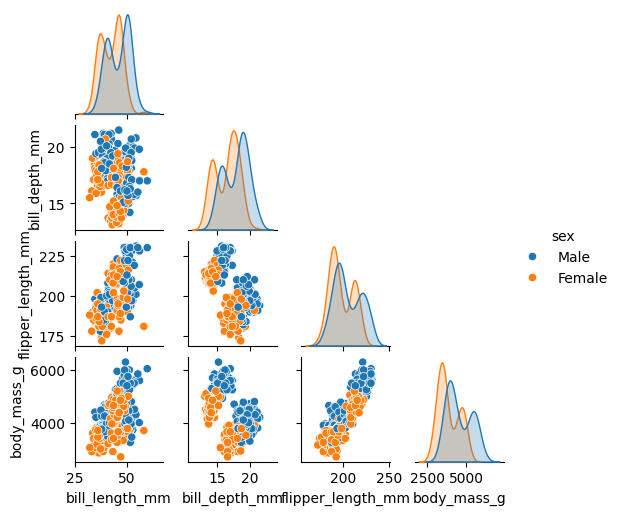

In [28]:
sns.pairplot(dfp2, corner=True, hue='sex', height=1.3);

It looks from this that *bill depth* and *body mass* should work well
to separate out genders.


Even here, the term **Decision Boundary** might make some intuitive sense
to you. What do you think it might mean?

Let's build the binary classifier using just these two columns, and 
get the confusion matrix just as before.

We'll do it all in one go, because we've seen all the steps before...

In [32]:
# extract the input/features X, and the output/labels y
X = dfp2.iloc[:, [3,5]].values
y = dfp2.iloc[:, 6].values
#print(X[0:4,:],'\n',y[0:4]) # optional, print a few, just to check
# bifurcate the data to get a 40% test set, and 60% training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40)
# get scaling parameters from the training data, 
scaler = StandardScaler()
scaler.fit(X_train)
# scale the training data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# now classify using k=2, p=1 - as before
classifier = KNeighborsClassifier(n_neighbors=2, p=1)
classifier.fit(X_train, y_train)
# and then make predictions from the test data 
y_pred = classifier.predict(X_test)
# compare the predictions with the hold-out (test) set, y_test
cm = confusion_matrix(y_test, y_pred)

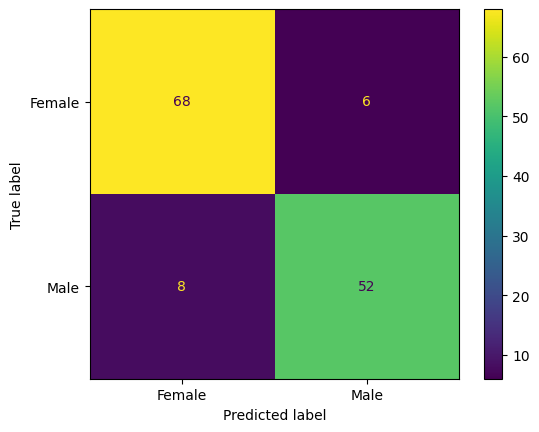

In [30]:
cmplot = ConfusionMatrixDisplay(cm, display_labels=classifier.classes_)
cmplot.plot()

## True and False Positives and Negatives

There are a few particularly important pieces of terminology that 
are associated with binary classifiers. 

- **TP**, *True Positives*: This is the number of test data points
that are labelled **POSITIVE** for which the classifier correctly
(**truly**) predicted them as **POSITIVE**.

- **FP**, *False Positives*: This is the number of test data points
that are labelled **NEGATIVE** for which the classifier incorrectly
(**falsely**) predicted them as **POSITIVE**.

Since we are regarding **Female** as **POSITIVE**, we can see these 
numbers in the first column above.

Furthermore,

- **FN**, *False Negatives*. This is the number of test data points
that are labelled **POSITIVE** for which the classifier incorrectly
(**falsely**) predicted them as **NEGATIVE**.

- **TN**, *True Negatives*. This is the number of test data points
that are labelled **NEGATIVE** for which the classifier incorrectly
(**truly**) predicted them as **NEGATIVE**.

These last two are in the second column.

Diagrammatically we have


$$
\begin{array}{rcc}
  \begin{array}{r}  \text{target, or true} \\ \text{label/class}  \end{array}\quad
  &
  \begin{array}{c}  + \\ -  \end{array}\!\!
  &
  \left(
  \begin{array}{cc}
  \mathrm{TP} & \mathrm{FN} \\
  \mathrm{FP} & \mathrm{TN} \\
  \end{array}
  \right)
\\
& & \begin{array}{cc} + & - \end{array}
\\
& & \text{output, or predicted}
\\
& & \text{label/class}
\\
\end{array}
$$


We can access these numbers in code as follows:

In [22]:
TP = cm[0,0]; FP = cm[1,0]; FN = cm[0,1]; TN = cm[1,1]
print(f'{TP=:<4d}, {FN=:<4d}, {FP=:<4d}, {TN=:<4d} (note the concise f-string)')

TP=60  , FN=8   , FP=13  , TN=53   (note the concise f-string)


# Related Formulae and Measures

Once we have these data we can compute a wide variety of different performance
indicators. Here are the most commonly used, where we use $\mathrm{P}$ and
$\mathrm{N}$ for the number of positives and negatives overall in the test set.

- **Prevalence**:

$$
\mathrm{Prevalence} = \frac{\mathrm{P}}{\mathrm{P}+\mathrm{N}}
$$

- TPR: **True Positive Rate**, *sensitivity*, *recall*:

$$
\mathrm{TPR} = \frac{\mathrm{TP}}{\mathrm{P}} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}
$$


- TNR: **True Negative Rate**, *specificity*, *selectivity*:

$$
\mathrm{TNR} = \frac{\mathrm{TN}}{\mathrm{N}} = \frac{\mathrm{TN}}{\mathrm{TN}+\mathrm{FP}}
$$

- FPR: **False Positive Rate**:

$$
\mathrm{FPR} = \frac{\mathrm{FP}}{\mathrm{N}} = \frac{\mathrm{FP}}{\mathrm{FP}+\mathrm{TN}}
$$

- FNR: **False Negative Rate**:

$$
\mathrm{FNR} = \frac{\mathrm{FN}}{\mathrm{P}} = \frac{\mathrm{FN}}{\mathrm{FN}+\mathrm{TP}}
$$

- **Accuracy**:

$$
\mathrm{Accuracy} = \frac{\mathrm{TP}+\mathrm{TN}}{\mathrm{P}+\mathrm{N}}
$$

- **Balanced Accuracy**:

$$
\mathrm{Balanced\ Accuracy} = \frac{1}{2}\left(\mathrm{TPR}+\mathrm{TNR}\right)
$$



- PPV: **Positive Predictive Value**, *precision*:

$$
\mathrm{PPV} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}}
$$



- NPV: **Negative Predictive Value**:

$$
\mathrm{NPV} = \frac{\mathrm{TN}}{\mathrm{TN}+\mathrm{FN}}
$$

- F1 score: this is the *harmonic mean* of precision and sensitivity:

$$
\mathrm{F1} = \left(
\frac{\displaystyle\left(\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}}\right)^{-1}
      +
      \left(\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}\right)^{-1}}{2}
\right)^{-1}
= \frac{2\,\mathrm{TP}}{2\,\mathrm{TP}+\mathrm{FP}+\mathrm{FN}}
$$

Let's calculate some of these

In [24]:
P=TP+FN
N=FP+TN
print('P (# positives) = ', P)
print('N (# negatives) = ', N)
print('TPR (recall)    = ', TP/(TP+FN))
print('PPV (precision) = ', TP/(TP+FP))
print('F1              = ', 2*TP/(2*TP+FP+FN))
print('Accuracy        = ', (TP+TN)/(P+N))

P (# positives) =  68
N (# negatives) =  66
TPR (recall)    =  0.8823529411764706
PPV (precision) =  0.821917808219178
F1              =  0.851063829787234
Accuracy        =  0.8432835820895522


## Logistic Regression

This is a technique for binary classification that is actually based 
on ideas from regression. The idea is to use a straight line to create a
**decision boundary** between the two classes.

The following logistic, or sigmoid, function is then used to create a 
switch from **off** to **on** as we cross that decision boundary.

This, for $a\in\mathbb{R}$, is the logistic function, often called the **sigmoid**:

$$
\sigma(x\mid a) = \frac{1}{1+\exp(-ax)},
\qquad\text{for } a >0.
$$

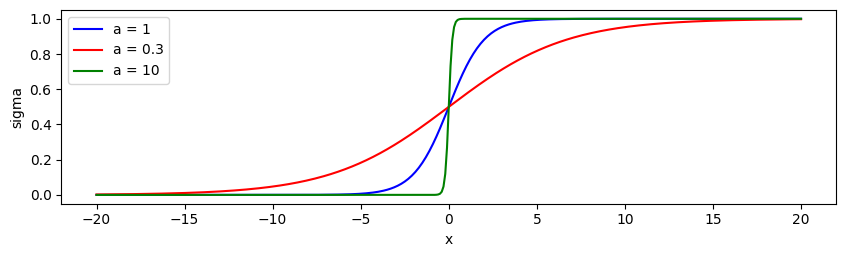

In [33]:
def sigma(x, a):
    return (1+np.exp(-a*x))**(-1)

x_vals = np.arange(-20, 20.1, 0.1)
y_vals_1 = sigma(x_vals, 1)
y_vals_03 = sigma(x_vals, 0.3)
y_vals_10 = sigma(x_vals, 10)

plt.figure(figsize=(10,4)); plt.gca().set_aspect(10)
plt.plot(x_vals, y_vals_1, color='blue', label='a = 1')
plt.plot(x_vals, y_vals_03, color='red', label='a = 0.3')
plt.plot(x_vals, y_vals_10, color='green', label='a = 10')
plt.xlabel('x'); plt.ylabel('sigma'); 
plt.legend()
plt.show()

It can be scaled by the choice of $a$, and also translated by $x_0$: 

$$
\sigma(x \mid a, x_0) = \frac{1}{1+\exp\big(-a(x-x_0)\big)}
$$

In [ ]:
def sigma(x, a, x0):
    return (1+np.exp(-a*(x-x0)))**(-1)

x_vals = np.arange(-20, 20.1, 0.1)
y_vals_0 = sigma(x_vals, 1, 0)
y_vals_5 = sigma(x_vals, 0.3, 5)
y_vals_m10 = sigma(x_vals, 10, -10)

plt.figure(figsize=(10,4)); plt.gca().set_aspect(10)
plt.plot(x_vals, y_vals_0, color='blue', label='a = 1')
plt.plot(x_vals, y_vals_5, color='red', label='a = 0.3')
plt.plot(x_vals, y_vals_m10, color='green', label='a = 10')
plt.xlabel('x'); plt.ylabel('sigma'); 
plt.legend()
plt.show()

In 2D we can write this kind of thing

$$
\sigma(x_1, x_2 \mid a, b, c) = \frac{1}{1+\exp\big(-(a x_1+b x_2+c)\big)}
$$

For example, with $a=-1$, $b=1$ and $c=0$ we have,

$$
\sigma(x_1, x_2 \mid -1, 1, 0) = \frac{1}{1+\exp\big(-(x_2-x_1)\big)}
$$

Now, along the line $x_1 = x_2$ we have $\sigma(x_1, x_2 \mid -1, 1, 0)=0.5$.

To one side of the line $\sigma \to 0$ and to the other side of the line 
$\sigma \to 1$. This means we have a switch, or a signal, that we can think
of as being off on one side of the line and switched on if we are on 
the other side.

This is **binary classification**.

In [ ]:
from matplotlib import cm
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection='3d')

# Define dimensions
Nx, Ny, Nz = 10, 10, 1
X, Y, Z = np.meshgrid(np.arange(-2,Nx,0.1), np.arange(-2,Ny,0.1), np.arange(Nz))
# Create sigmoid surface using the meshgrid
sigmoid = (1+np.exp(-(Y-X)))**(-1)

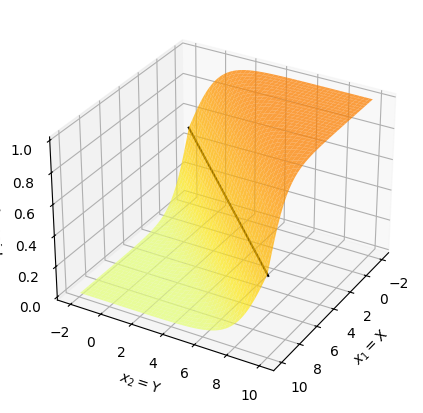

In [40]:
# plot surface
ax.plot_surface(X[:, :, 0], Y[:, :, 0], sigmoid[:, :, 0], cmap=cm.Wistia, alpha=0.75)
ax.set_xlabel('$x_1=$X'); ax.set_ylabel('$x_2=$Y'); ax.set_zlabel('sigmoid')
# plot line Y=X at height Z = 0.5
ax.plot([-2,10], [-2,10], [0.5,0.5], color='black')
ax.view_init(30, 30);

### The Iris Data Set

We are going to illustrate the idea behind logistic regression using the Iris Data Set.
See, for example, <https://en.wikipedia.org/wiki/Iris_flower_data_set> for the details.


This is very well known. Something that any aspiring Machne Learning engineer
ought to be aware of.

It is not without controversy though. It was used by Fisher, and Fisher was associated with
**eugenics**. You can read more about that here:

<https://www.nature.com/articles/s41437-020-00394-6>

If this offends you then you can replace the use of the Iris data below with 
the penguins data we have been using.

In [ ]:
# load it in and take a look
sns.get_dataset_names()
dfi = sns.load_dataset('iris')
dfi.head()

In [ ]:
sns.pairplot(dfi, hue='species', height = 1.5)

In [ ]:
# we want a binary classifier so we drop the virginica data
dfid = dfi[ (dfi['species'] != 'virginica') == True ]
sns.pairplot(dfid, hue='species', height = 1.5)

In [ ]:
dfid.head()

In [ ]:
# let's use petal length and sepal width as our features
xall = dfid.iloc[:,[1,2]].values
# and species as our label
yall = dfid.iloc[:, 4].values
print(xall[0:5,:], yall[0:5])

In [ ]:
# select the setosa and versicolor feature rows
x_set = xall[yall == 'setosa',:] 
x_ver = xall[yall == 'versicolor',:]
# set the vertical coordinate for the 3D surface plot
z_set = (1+np.exp(-(x_set[:,1]-x_set[:,0]) ))**(-1)
z_ver = (1+np.exp(-(x_ver[:,1]-x_ver[:,0]) ))**(-1)

In [ ]:
fig = plt.figure(figsize=(6,6)) # some of this set up was done above
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X[:, :, 0], Y[:, :, 0], sigmoid[:, :, 0], cmap=cm.Wistia, alpha=0.75)
ax.scatter(x_set[:,0], x_set[:,1], z_set, c='black', marker='o')
ax.scatter(x_ver[:,0], x_ver[:,1], z_ver, c='red', marker='o')
ax.set_xlabel('sepal width'); ax.set_ylabel('petal length')
ax.set_zlabel('logistic values'); ax.view_init(10, 10); plt.show()

### Discussion

What you see here is that the data are being separated by the sigmoid,
or logistic, function's **ramp** from $0$ to $1$. 

The idea behind **logistic regression** is to use training data to 
determine a line $ax_1+bx_2+c=0$ so that  

$$
\sigma(x_1, x_2 \mid a, b, c) = \frac{1}{1+\exp\big(-(a x_1+b x_2+c)\big)}
$$

can be used as a classifier. The line is then a **decision boundary**.

For example, for input feature values
$x_1$ and $x_2$, and for $a$, $b$ and $c$ determined by the regression,
we would classify as:

$$
\left\{\begin{array}{ll}
\sigma(x_1, x_2 \mid a, b, c) 
\ge 0.5 & (x_1, x_2)\text{ indicate Class 1 (e.g. versicolor)};
\\
\sigma(x_1, x_2 \mid a, b, c) 
< 0.5 & (x_1, x_2)\text{ indicate Class 2 (e.g. setosa)};
\end{array}\right.
$$

# TO BE FINALISED

No further theoretical details or explanations of Logistic Regression are
required for this module, although we will show how to implement it and you
will be expected to be able to mimic that implementation in similar 
contexts and for similar data sets.

Logstic regression 

MA3627, 3632N Data Mining and AI for Big Data Analytics (opt M, comp MCS, FM, MDS)

MA2619,MA2628N Applied Statistics (not MCS)





### Technical Details

Suppose we use $\boldsymbol{\theta} = (\theta_0, \theta_1, \theta_2)^T$ with
$\boldsymbol{x} = (1, x_1, x_2)^T$ to represent the decision boundary with
$\boldsymbol{\theta}^T\boldsymbol{x}=0$. Then, with

$$
p = \frac{1}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
$$

we get 

$$
1-p
= 1 - \frac{1}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
= \frac{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
- \frac{1}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
= \frac{\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}.
$$

Hence,

$$
\frac{p}{1-p}
= \frac{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}{\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
\frac{1}{1+\exp(-\boldsymbol{\theta}^T\boldsymbol{x})}
=\exp(\boldsymbol{\theta}^T\boldsymbol{x})
$$

and $0< p < 1$ - so $p$ is a probability and $p/(p-1)$ the **odds**. 

### The log-odds

Taking the log of both sides 

$$
\ln\left(\frac{p}{1-p}\right)
=\ln\exp(\boldsymbol{\theta}^T\boldsymbol{x})
$$

Therefore, simplifying,

$$
\ln\left(\frac{p}{1-p}\right)
=\boldsymbol{\theta}^T\boldsymbol{x}
$$

and there is the connection to linear regression. The decision boundary
models the log-odds.

### How Do We Do Logistic Regression?

Suppose we have a training set of features $\boldsymbol{x}_1$,
$\boldsymbol{x}_2$, $\boldsymbol{x}_3$, $\ldots$, with corresponding
labels $y_1$, $y_2$, $y_3$, $\ldots$. We suppose that the labels are
either $y=0$ or $y=1$ to represent the **binary classification**.

Then, for a given pair $(\boldsymbol{x}_k, y_k)$ with 
$\boldsymbol{x}_k = (x_{1,k}, x_{2,k})^T$, we can set up
the **squared loss**,

$$
\big\vert y_k - \sigma(x_{1,k}, x_{2,k} \mid a, b, c)\big\vert^2
$$

and use it to form a TSE or MSE cost over the training set. We
then choose $a$, $b$ and $c$ to minimise this cost.

There is no closed-form solution to this (no equivalent of
the Normal Equations), but we can use numerical techniques.

It can (of course) be done in `sklearn`. The details are here: 

<https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html>

along with an actual example on the Iris data set.

## Technical Notes, Production and Archiving

**Ignore the material below**. What follows is not relevant to the material being taught.

#### Production Workflow

- Finalise the notebook material above
- Clear and fresh run of entire notebook
- Create html slide show:
  - `jupyter nbconvert --to slides 11_regress.ipynb `
- Set `OUTPUTTING=1` below
- Comment out the display of web-sourced diagrams
- Clear and fresh run of entire notebook
- Comment back in the display of web-sourced diagrams
- Clear all cell output
- Set `OUTPUTTING=0` below
- Save
- git add, commit and push to FML
- copy PDF, HTML etc to web site
  - git add, commit and push
- rebuild binder

Some of this originated from

<https://stackoverflow.com/questions/38540326/save-html-of-a-jupyter-notebook-from-within-the-notebook>

These lines create a back up of the notebook. They can be ignored.

At some point this is better as a bash script outside of the notebook

In [ ]:
%%bash
NBROOTNAME=03_logreg
OUTPUTTING=0

if [ $OUTPUTTING -eq 1 ]; then
  jupyter nbconvert --to slides $NBROOTNAME.ipynb
  cp $NBROOTNAME.html ../backups/$(date +"%m_%d_%Y-%H%M%S")_$NBROOTNAME.html
  mv -f $NBROOTNAME.html ../formats/html/

  jupyter nbconvert --to pdf $NBROOTNAME.ipynb
  cp $NBROOTNAME.pdf ../backups/$(date +"%m_%d_%Y-%H%M%S")_$NBROOTNAME.pdf
  mv -f $NBROOTNAME.pdf ../formats/pdf/

  jupyter nbconvert --to script $NBROOTNAME.ipynb
  cp $NBROOTNAME.py ../backups/$(date +"%m_%d_%Y-%H%M%S")_$NBROOTNAME.py
  mv -f $NBROOTNAME.py ../formats/py/
  echo; echo 'Finished generating html, pdf and py output versions'
else
  echo 'Not Generating html, pdf and py output versions'
fi